In [2]:
import sys
import os

# Adiciona o caminho raiz do projeto
sys.path.append(os.path.abspath(".."))

from data.synthetic_generator import generate_synthetic_data

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
df = generate_synthetic_data(n_products=3, n_days=180)

df.head()

,date,product_id,price,cost,cac,quantity,promotion_flag
0,2025-08-26 12:44:31.697428,1,123.871921,84.057272,8.899863,144.791088,0
1,2025-08-27 12:44:31.697428,1,155.589634,84.057272,5.514612,151.079238,1
2,2025-08-28 12:44:31.697428,1,162.735193,84.057272,10.308478,93.846781,0
3,2025-08-29 12:44:31.697428,1,145.057386,84.057272,15.798625,104.134711,0
4,2025-08-30 12:44:31.697428,1,150.061427,84.057272,8.487347,101.997176,0


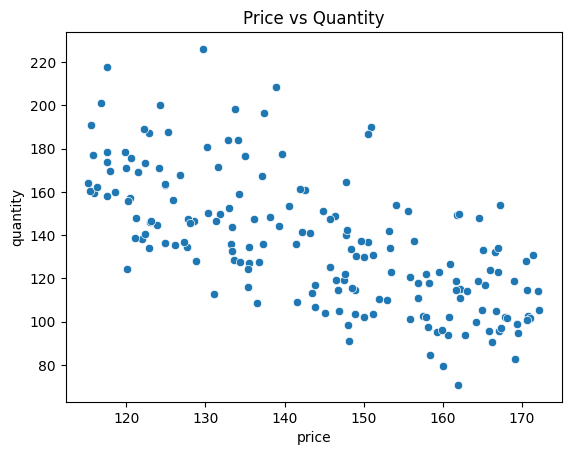

In [4]:
product_df = df[df["product_id"] == 1]

sns.scatterplot(x="price", y="quantity", data=product_df)
plt.title("Price vs Quantity")
plt.show()

In [5]:
import numpy as np
import statsmodels.api as sm

product_df = df[df["product_id"] == 1].copy()

product_df["log_price"] = np.log(product_df["price"])
product_df["log_quantity"] = np.log(product_df["quantity"])

In [6]:
X = sm.add_constant(product_df["log_price"])
y = product_df["log_quantity"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           log_quantity   R-squared:                       0.467
Model:                            OLS   Adj. R-squared:                  0.464
Method:                 Least Squares   F-statistic:                     155.8
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           4.32e-26
Time:                        12:48:05   Log-Likelihood:                 72.953
No. Observations:                 180   AIC:                            -141.9
Df Residuals:                     178   BIC:                            -135.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.1718      0.503     22.197      0.0

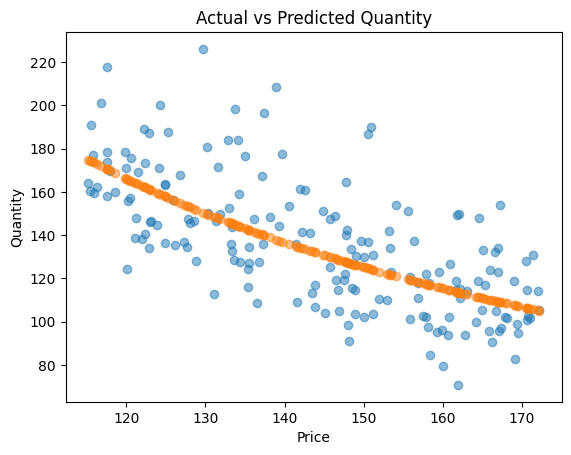

In [7]:
# Previsões log
product_df["log_pred"] = model.predict(X)

# Converter de volta para escala original
product_df["pred_quantity"] = np.exp(product_df["log_pred"])

plt.scatter(product_df["price"], product_df["quantity"], alpha=0.5)
plt.scatter(product_df["price"], product_df["pred_quantity"], alpha=0.5)
plt.xlabel("Price")
plt.ylabel("Quantity")
plt.title("Actual vs Predicted Quantity")
plt.show()

In [8]:
df["month"] = pd.to_datetime(df["date"]).dt.month

features = ["price", "cac", "promotion_flag", "month"]
X = df[features]
y = df["quantity"]

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_rf = RandomForestRegressor(n_estimators=200, random_state=42)
model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse

np.float64(27.221867171904663)

In [10]:
import pandas as pd

importance = pd.Series(
    model_rf.feature_importances_,
    index=features
).sort_values(ascending=False)

importance

price             0.537410
month             0.194753
cac               0.153833
promotion_flag    0.114003
dtype: float64

In [11]:
product_id = 1

product_df = df[df["product_id"] == product_id].copy()

cost = product_df["cost"].iloc[0]
avg_cac = product_df["cac"].mean()

cost, avg_cac

(np.float64(84.05727220815025), np.float64(16.94805759392014))

In [12]:
def profit_function(price, model, cost, cac, month=6, promotion_flag=0):
    
    X_sim = pd.DataFrame({
        "price": [price],
        "cac": [cac],
        "promotion_flag": [promotion_flag],
        "month": [month]
    })
    
    predicted_quantity = model.predict(X_sim)[0]
    
    profit = (price - cost - cac) * predicted_quantity
    
    return profit

In [15]:
price_range = np.linspace(80, 250, 200)

profits = [
    profit_function(p, model_rf, cost, avg_cac)
    for p in price_range
]

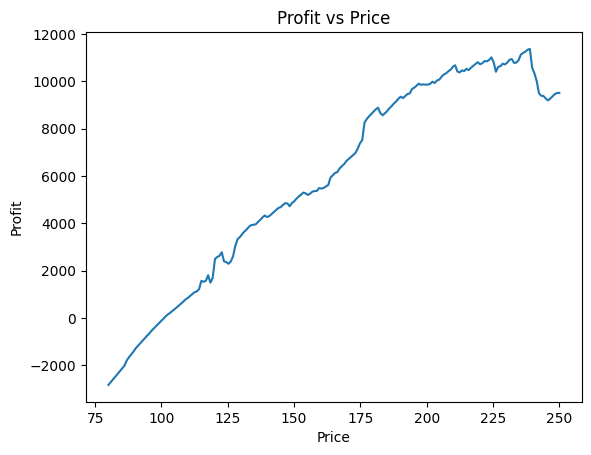

In [16]:
plt.plot(price_range, profits)
plt.xlabel("Price")
plt.ylabel("Profit")
plt.title("Profit vs Price")
plt.show()

In [17]:
optimal_index = np.argmax(profits)
optimal_price = price_range[optimal_index]
optimal_profit = profits[optimal_index]

optimal_price, optimal_profit

(np.float64(238.89447236180905), np.float64(11367.707648890679))

In [18]:
import statsmodels.api as sm
import numpy as np

df_model = df.copy()

df_model["log_quantity"] = np.log(df_model["quantity"])
df_model["log_price"] = np.log(df_model["price"])

features = ["log_price", "cac", "promotion_flag", "month"]
X = df_model[features]
X = sm.add_constant(X)

y = df_model["log_quantity"]

model_struct = sm.OLS(y, X).fit()

print(model_struct.summary())

                            OLS Regression Results                            
Dep. Variable:           log_quantity   R-squared:                       0.304
Model:                            OLS   Adj. R-squared:                  0.299
Method:                 Least Squares   F-statistic:                     58.48
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           5.98e-41
Time:                        14:57:30   Log-Likelihood:                 8.5758
No. Observations:                 540   AIC:                            -7.152
Df Residuals:                     535   BIC:                             14.31
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              6.5457      0.165     39.

In [19]:
import numpy as np

# extrair coeficientes
alpha = model_struct.params["const"]
beta_price = model_struct.params["log_price"]
beta_cac = model_struct.params["cac"]
beta_promo = model_struct.params["promotion_flag"]
beta_month = model_struct.params["month"]

def quantity_structural(price, cac, promo=0, month=6):
    log_q = (
        alpha
        + beta_price * np.log(price)
        + beta_cac * cac
        + beta_promo * promo
        + beta_month * month
    )
    return np.exp(log_q)

def profit_structural(price, cost, cac, promo=0, month=6):
    q = quantity_structural(price, cac, promo, month)
    return (price - cost - cac) * q

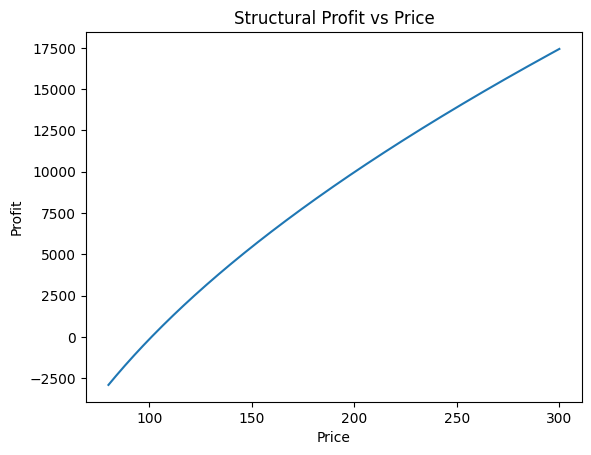

In [20]:
price_range = np.linspace(80, 300, 300)

profits_struct = [
    profit_structural(p, cost, avg_cac)
    for p in price_range
]

plt.plot(price_range, profits_struct)
plt.xlabel("Price")
plt.ylabel("Profit")
plt.title("Structural Profit vs Price")
plt.show()

In [21]:
def diagnose_elasticity(beta):
    
    if beta < -1:
        return {
            "regime": "interior_solution",
            "message": "Elastic demand. Profit-maximizing price exists internally."
        }
    
    elif -1 < beta < 0:
        return {
            "regime": "boundary_solution",
            "message": "Inelastic demand. Profit increases with price within observed range."
        }
    
    else:
        return {
            "regime": "model_issue",
            "message": "Positive or zero elasticity. Model may be misspecified."
        }

In [22]:
diagnose_elasticity(beta_price)

{'regime': 'boundary_solution',
 'message': 'Inelastic demand. Profit increases with price within observed range.'}

In [23]:
def optimize_price_structural(
    cost,
    cac,
    beta,
    price_min,
    price_max
):
    
    diagnosis = diagnose_elasticity(beta)
    
    if diagnosis["regime"] == "interior_solution":
        
        # fórmula fechada para demanda isoelástica
        optimal_price = (beta / (beta + 1)) * (cost + cac)
        
        return {
            "regime": "interior_solution",
            "optimal_price": optimal_price,
            "note": "Closed-form economic solution."
        }
    
    elif diagnosis["regime"] == "boundary_solution":
        
        return {
            "regime": "boundary_solution",
            "optimal_price": price_max,
            "note": "Profit increases with price in feasible range."
        }
    
    else:
        
        return {
            "regime": "model_issue",
            "optimal_price": None,
            "note": "Model requires review."
        }

In [24]:
optimize_price_structural(
    cost=cost,
    cac=avg_cac,
    beta=beta_price,
    price_min=80,
    price_max=300
)

{'regime': 'boundary_solution',
 'optimal_price': 300,
 'note': 'Profit increases with price in feasible range.'}

In [25]:
def elasticity_stat_diagnostics(model, beta_name="log_price"):
    
    coef = model.params[beta_name]
    p_value = model.pvalues[beta_name]
    ci_lower, ci_upper = model.conf_int().loc[beta_name]
    
    crosses_unit_elastic = ci_lower < -1 < ci_upper
    
    if p_value > 0.05:
        reliability = "not_significant"
    else:
        reliability = "significant"
    
    return {
        "coef": coef,
        "p_value": p_value,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "crosses_-1": crosses_unit_elastic,
        "reliability": reliability
    }

In [26]:
elasticity_stat_diagnostics(model_struct)

{'coef': np.float64(-0.34526103123009594),
 'p_value': np.float64(1.9900580269207067e-24),
 'ci_lower': -0.40851970976123264,
 'ci_upper': -0.28200235269895924,
 'crosses_-1': False,
 'reliability': 'significant'}

In [27]:
def robust_optimize_price(
    model,
    cost,
    cac,
    price_min,
    price_max
):
    
    diag = elasticity_stat_diagnostics(model)
    beta = diag["coef"]
    
    if diag["reliability"] == "not_significant":
        return {
            "regime": "model_unreliable",
            "optimal_price": None,
            "note": "Elasticity not statistically significant."
        }
    
    if diag["crosses_-1"]:
        return {
            "regime": "uncertain_regime",
            "optimal_price": None,
            "note": "Elasticity confidence interval crosses -1."
        }
    
    if beta < -1:
        optimal_price = (beta / (beta + 1)) * (cost + cac)
        return {
            "regime": "interior_solution",
            "optimal_price": optimal_price,
            "note": "Interior economic solution."
        }
    
    else:
        return {
            "regime": "boundary_solution",
            "optimal_price": price_max,
            "note": "Inelastic demand within range."
        }

In [28]:
robust_optimize_price(
    model_struct,
    cost,
    avg_cac,
    80,
    300
)

{'regime': 'boundary_solution',
 'optimal_price': 300,
 'note': 'Inelastic demand within range.'}

In [29]:
def quantity_with_saturation(price, cac, promo=0, month=6, delta=0.01):
    
    base_quantity = quantity_structural(price, cac, promo, month)
    
    saturation_term = 1 + delta * price
    
    return base_quantity / saturation_term


def profit_with_saturation(price, cost, cac, promo=0, month=6, delta=0.01):
    
    q = quantity_with_saturation(price, cac, promo, month, delta)
    
    return (price - cost - cac) * q

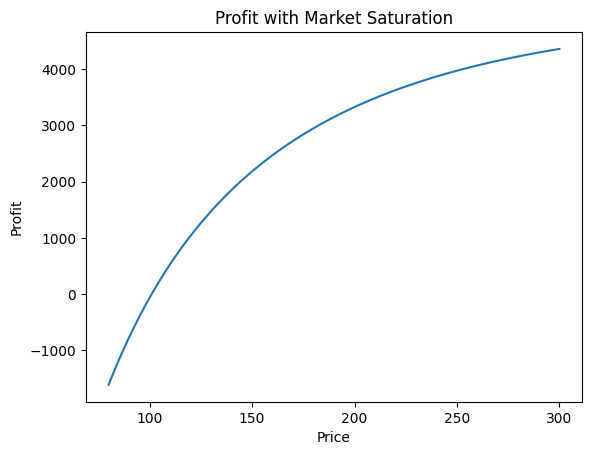

In [30]:
price_range = np.linspace(80, 300, 300)

profits_sat = [
    profit_with_saturation(p, cost, avg_cac, delta=0.01)
    for p in price_range
]

plt.plot(price_range, profits_sat)
plt.xlabel("Price")
plt.ylabel("Profit")
plt.title("Profit with Market Saturation")
plt.show()

In [32]:
delta=0.05

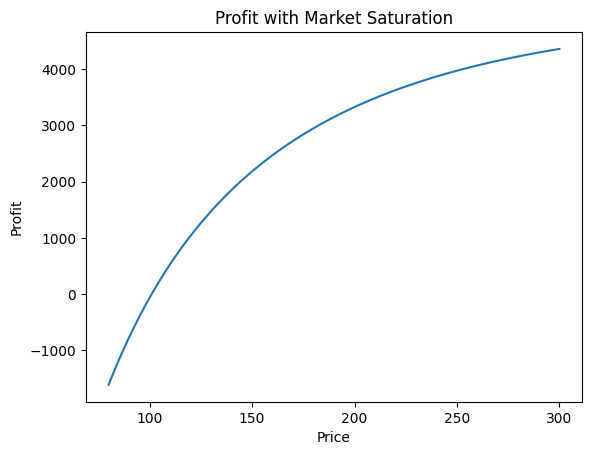

In [33]:
plt.plot(price_range, profits_sat)
plt.xlabel("Price")
plt.ylabel("Profit")
plt.title("Profit with Market Saturation")
plt.show()

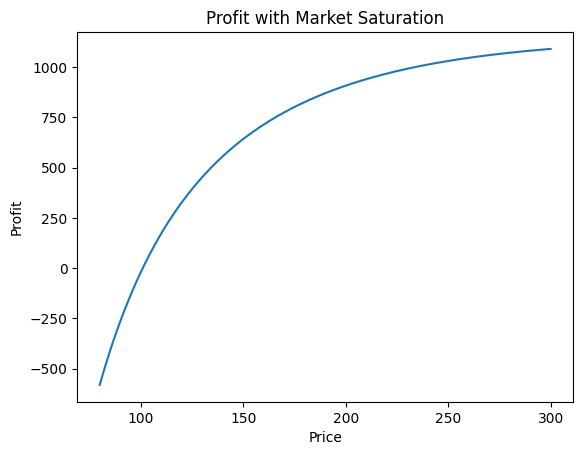

In [34]:
price_range = np.linspace(80, 300, 300)

profits_sat = [
    profit_with_saturation(p, cost, avg_cac, delta=0.05)
    for p in price_range
]

plt.plot(price_range, profits_sat)
plt.xlabel("Price")
plt.ylabel("Profit")
plt.title("Profit with Market Saturation")
plt.show()

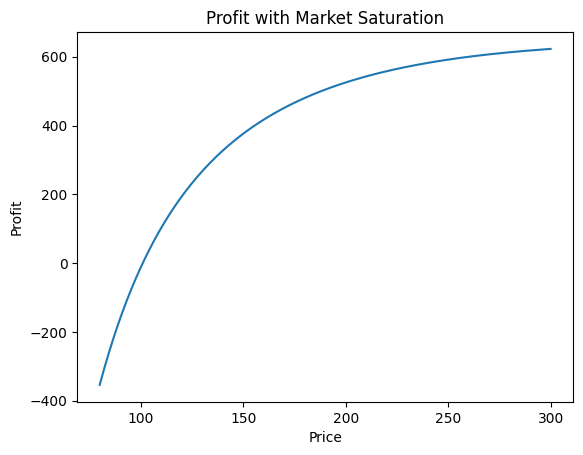

In [35]:
price_range = np.linspace(80, 300, 300)

profits_sat = [
    profit_with_saturation(p, cost, avg_cac, delta=0.09)
    for p in price_range
]

plt.plot(price_range, profits_sat)
plt.xlabel("Price")
plt.ylabel("Profit")
plt.title("Profit with Market Saturation")
plt.show()

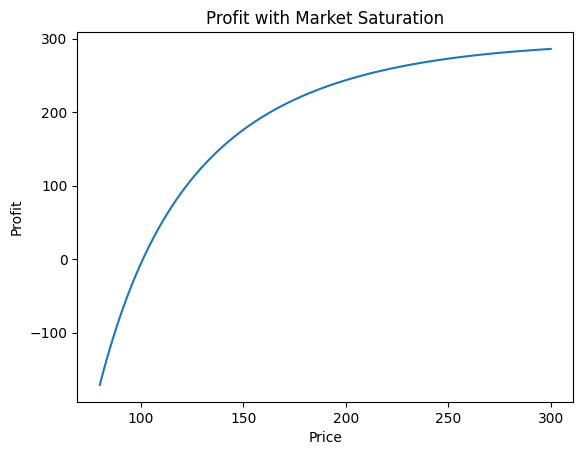

In [36]:
price_range = np.linspace(80, 300, 300)

profits_sat = [
    profit_with_saturation(p, cost, avg_cac, delta=0.2)
    for p in price_range
]

plt.plot(price_range, profits_sat)
plt.xlabel("Price")
plt.ylabel("Profit")
plt.title("Profit with Market Saturation")
plt.show()

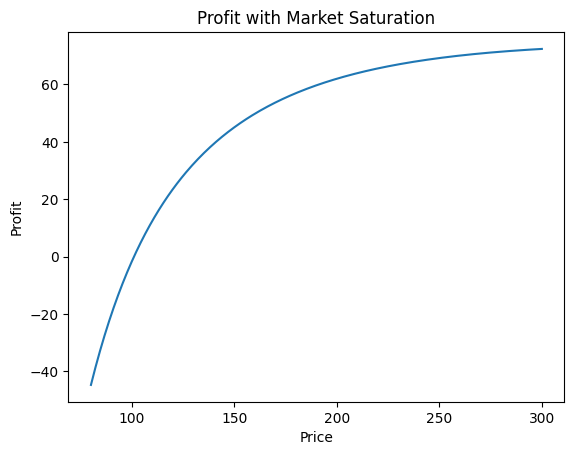

In [37]:
price_range = np.linspace(80, 300, 300)

profits_sat = [
    profit_with_saturation(p, cost, avg_cac, delta=0.8)
    for p in price_range
]

plt.plot(price_range, profits_sat)
plt.xlabel("Price")
plt.ylabel("Profit")
plt.title("Profit with Market Saturation")
plt.show()

In [38]:
def fit_structural_model(df, entity_column, entity_value):
    
    df_entity = df[df[entity_column] == entity_value].copy()
    
    df_entity["log_quantity"] = np.log(df_entity["quantity"])
    df_entity["log_price"] = np.log(df_entity["price"])
    
    features = ["log_price", "cac", "promotion_flag", "month"]
    X = df_entity[features]
    X = sm.add_constant(X)
    
    y = df_entity["log_quantity"]
    
    model = sm.OLS(y, X).fit()
    
    return model

In [39]:
model_product_1 = fit_structural_model(df, "product_id", 1)

In [40]:
model_p1 = fit_structural_model(df, "product_id", 1)
print(model_p1.summary())

                            OLS Regression Results                            
Dep. Variable:           log_quantity   R-squared:                       0.694
Model:                            OLS   Adj. R-squared:                  0.687
Method:                 Least Squares   F-statistic:                     99.16
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           6.42e-44
Time:                        15:38:38   Log-Likelihood:                 122.90
No. Observations:                 180   AIC:                            -235.8
Df Residuals:                     175   BIC:                            -219.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             11.2865      0.388     29.

In [41]:
robust_optimize_price(
    model_p1,
    cost,
    avg_cac,
    80,
    300
)

{'regime': 'interior_solution',
 'optimal_price': np.float64(469.9418228872047),
 'note': 'Interior economic solution.'}

In [42]:
def trust_region_check(optimal_price, observed_min, observed_max, tolerance=0.3):
    
    range_width = observed_max - observed_min
    allowed_upper = observed_max + tolerance * range_width
    
    if optimal_price > allowed_upper:
        return {
            "status": "excessive_extrapolation",
            "allowed_upper_bound": allowed_upper
        }
    else:
        return {
            "status": "within_trust_region"
        }

In [43]:
observed_min = df[df["product_id"] == 1]["price"].min()
observed_max = df[df["product_id"] == 1]["price"].max()

trust_region_check(469.94, observed_min, observed_max)

{'status': 'excessive_extrapolation',
 'allowed_upper_bound': np.float64(189.25980136654871)}

In [44]:
def enterprise_optimize_price(
    model,
    df,
    entity_column,
    entity_value,
    cost,
    cac,
    tolerance=0.3
):
    
    diag = elasticity_stat_diagnostics(model)
    beta = diag["coef"]
    
    observed_prices = df[df[entity_column] == entity_value]["price"]
    observed_min = observed_prices.min()
    observed_max = observed_prices.max()
    
    trust_upper = observed_max + tolerance * (observed_max - observed_min)
    
    if diag["reliability"] != "significant":
        return {
            "regime": "model_unreliable"
        }
    
    if beta < -1:
        theoretical_price = (beta / (beta + 1)) * (cost + cac)
        
        if theoretical_price > trust_upper:
            return {
                "regime": "interior_solution_extrapolated",
                "theoretical_price": theoretical_price,
                "trust_upper_bound": trust_upper,
                "recommended_price": trust_upper
            }
        else:
            return {
                "regime": "interior_solution",
                "recommended_price": theoretical_price
            }
    
    else:
        return {
            "regime": "boundary_solution",
            "recommended_price": trust_upper
        }

In [45]:
enterprise_optimize_price(
    model_p1,
    df,
    "product_id",
    1,
    cost,
    avg_cac
)

{'regime': 'interior_solution_extrapolated',
 'theoretical_price': np.float64(469.9418228872047),
 'trust_upper_bound': np.float64(189.25980136654871),
 'recommended_price': np.float64(189.25980136654871)}

In [46]:
def create_bundle_dataset(df, product_a, product_b, bundle_id=999):
    
    df_a = df[df["product_id"] == product_a].copy()
    df_b = df[df["product_id"] == product_b].copy()
    
    bundle = df_a.copy()
    
    bundle["product_id"] = bundle_id
    
    # preço do bundle = soma com desconto
    discount = 0.15
    bundle["price"] = (df_a["price"].values + df_b["price"].values) * (1 - discount)
    
    # demanda do bundle (simplificação estrutural)
    bundle["quantity"] = np.minimum(df_a["quantity"].values, df_b["quantity"].values) * 0.8
    
    bundle["cost"] = df_a["cost"].values + df_b["cost"].values
    
    return bundle

In [47]:
bundle_df = create_bundle_dataset(df, 1, 2)
df_extended = pd.concat([df, bundle_df], ignore_index=True)

In [48]:
model_bundle = fit_structural_model(df_extended, "product_id", 999)

In [49]:
def simulate_population(
    n_consumers=10000,
    mean_A=150,
    mean_B=120,
    std_A=30,
    std_B=25,
    correlation=0.3
):
    mean = [mean_A, mean_B]
    cov = [
        [std_A**2, correlation*std_A*std_B],
        [correlation*std_A*std_B, std_B**2]
    ]
    
    wtp = np.random.multivariate_normal(mean, cov, n_consumers)
    
    return wtp[:,0], wtp[:,1]

In [50]:
def demand_individual(wtp, price):
    return np.mean(wtp >= price)

def demand_bundle(wtp_A, wtp_B, price_bundle):
    return np.mean((wtp_A + wtp_B) >= price_bundle)

In [51]:
def profit_individual(price, wtp, cost):
    demand = demand_individual(wtp, price)
    return (price - cost) * demand

def profit_bundle(price_bundle, wtp_A, wtp_B, cost_bundle):
    demand = demand_bundle(wtp_A, wtp_B, price_bundle)
    return (price_bundle - cost_bundle) * demand

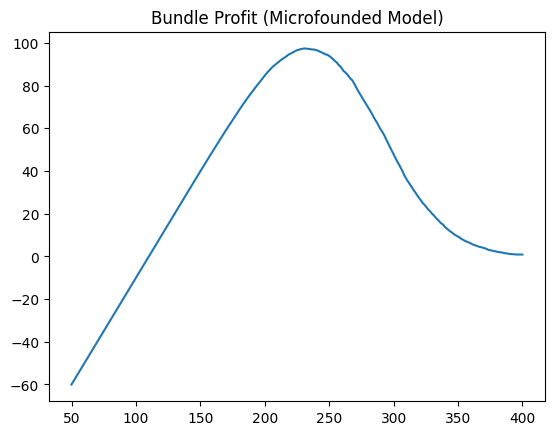

In [52]:
wtp_A, wtp_B = simulate_population()

cost_A = 60
cost_B = 50
cost_bundle = cost_A + cost_B

prices = np.linspace(50, 400, 200)

profits_bundle = [
    profit_bundle(p, wtp_A, wtp_B, cost_bundle)
    for p in prices
]

plt.plot(prices, profits_bundle)
plt.title("Bundle Profit (Microfounded Model)")
plt.show()

In [53]:
from scipy.stats import norm
from scipy.optimize import minimize

def calibrate_wtp_distribution(mean_price, elasticity, market_size=1):
    
    # Função que mede erro entre elasticidade teórica e desejada
    def objective(params):
        mu, sigma = params
        
        if sigma <= 0:
            return 1e6
        
        # demanda como proporção acima do preço médio
        demand = 1 - norm.cdf(mean_price, mu, sigma)
        
        # derivada da demanda
        pdf = norm.pdf(mean_price, mu, sigma)
        
        # elasticidade teórica
        elasticity_model = -(mean_price / demand) * pdf
        
        return (elasticity_model - elasticity)**2
    
    result = minimize(objective, x0=[mean_price, mean_price*0.2])
    
    mu_est, sigma_est = result.x
    
    return mu_est, sigma_est

In [54]:
mean_price_p1 = df[df["product_id"]==1]["price"].mean()
beta_p1 = model_p1.params["log_price"]

mu_A, sigma_A = calibrate_wtp_distribution(mean_price_p1, beta_p1)

In [55]:
def generate_calibrated_population(mu, sigma, n=10000):
    return np.random.normal(mu, sigma, n)

In [60]:
model_p2 = fit_structural_model(df, "product_id", 2)

model_p2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           log_quantity   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.812
Method:                 Least Squares   F-statistic:                     194.6
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           2.76e-63
Time:                        16:38:02   Log-Likelihood:                 116.39
No. Observations:                 180   AIC:                            -222.8
Df Residuals:                     175   BIC:                            -206.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             15.7473      0.444     35.459      0.000      14.871      16.624
log_price         -2.0460      0.082    -25.058      0.000      -2.207      -1.885
cac                0.0005      0.001      0.349      0.727      -0.002       0.003
promotion_flag     0.2676      0.027      9.821      0.000       0.214       0.321
month             -0.0202      0.002     -8.782      0.000      -0.025      -0.016
==============================================================================
Omnibus:                        2.749   Durbin-Watson:                   1.196
Prob(Omnibus):                  0.253   Jarque-Bera (JB):                2.746
Skew:                          -0.296   Prob(JB):                        0.253
Kurtosis:                       2.878   Cond. No.                         988.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [61]:
mean_price_p2 = df[df["product_id"] == 2]["price"].mean()
beta_p2 = model_p2.params["log_price"]

mu_B, sigma_B = calibrate_wtp_distribution(mean_price_p2, beta_p2)

mu_B, sigma_B

(np.float64(242.90646410769924), np.float64(68.5967835652333))

In [62]:
wtp_A = generate_calibrated_population(mu_A, sigma_A)
wtp_B = generate_calibrated_population(mu_B, sigma_B)

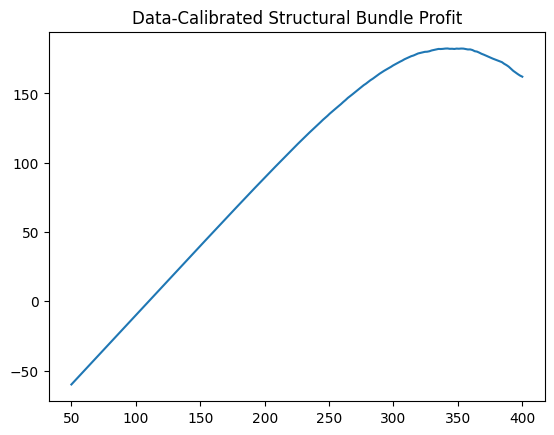

In [63]:
prices = np.linspace(50, 400, 200)
cost_bundle = cost_A + cost_B

profits_bundle = [
    profit_bundle(p, wtp_A, wtp_B, cost_bundle)
    for p in prices
]

plt.plot(prices, profits_bundle)
plt.title("Data-Calibrated Structural Bundle Profit")
plt.show()

In [64]:
def optimal_individual_price(wtp, cost, price_range):
    profits = [
        profit_individual(p, wtp, cost)
        for p in price_range
    ]
    idx = np.argmax(profits)
    return price_range[idx], profits[idx]

In [65]:
opt_A_price, opt_A_profit = optimal_individual_price(wtp_A, cost_A, prices)
opt_B_price, opt_B_profit = optimal_individual_price(wtp_B, cost_B, prices)

opt_A_price, opt_A_profit, opt_B_price, opt_B_profit

(np.float64(152.0100502512563),
 np.float64(57.26705527638192),
 np.float64(201.25628140703517),
 np.float64(110.17507537688442))

In [66]:
max_bundle_profit = max(profits_bundle)
max_bundle_profit

np.float64(182.36679396984928)

In [67]:
def enterprise_market_strategy(
    wtp_A,
    wtp_B,
    cost_A,
    cost_B,
    price_range
):
    
    # Ótimos individuais
    opt_A_price, opt_A_profit = optimal_individual_price(wtp_A, cost_A, price_range)
    opt_B_price, opt_B_profit = optimal_individual_price(wtp_B, cost_B, price_range)
    
    total_separate_profit = opt_A_profit + opt_B_profit
    
    # Ótimo bundle
    cost_bundle = cost_A + cost_B
    
    bundle_profits = [
        profit_bundle(p, wtp_A, wtp_B, cost_bundle)
        for p in price_range
    ]
    
    idx_bundle = np.argmax(bundle_profits)
    opt_bundle_price = price_range[idx_bundle]
    opt_bundle_profit = bundle_profits[idx_bundle]
    
    # Comparação
    if opt_bundle_profit > total_separate_profit:
        regime = "mixed_bundling_recommended"
        incremental_gain = opt_bundle_profit - total_separate_profit
        gain_pct = incremental_gain / total_separate_profit
    else:
        regime = "separate_sales_optimal"
        incremental_gain = 0
        gain_pct = 0
    
    return {
        "regime": regime,
        "separate_profit": total_separate_profit,
        "bundle_profit": opt_bundle_profit,
        "optimal_price_A": opt_A_price,
        "optimal_price_B": opt_B_price,
        "optimal_bundle_price": opt_bundle_price,
        "incremental_gain": incremental_gain,
        "incremental_gain_pct": gain_pct
    }

In [68]:
enterprise_market_strategy(
    wtp_A,
    wtp_B,
    cost_A,
    cost_B,
    prices
)

{'regime': 'mixed_bundling_recommended',
 'separate_profit': np.float64(167.44213065326633),
 'bundle_profit': np.float64(182.36679396984928),
 'optimal_price_A': np.float64(152.0100502512563),
 'optimal_price_B': np.float64(201.25628140703517),
 'optimal_bundle_price': np.float64(341.9597989949749),
 'incremental_gain': np.float64(14.92466331658295),
 'incremental_gain_pct': np.float64(0.08913326209093966)}

In [69]:
from src.structural_market import calibrate_wtp_distribution

In [70]:
from src.elasticity_engine import fit_structural_model, elasticity_stat_diagnostics

In [71]:
streamlit run app.py

SyntaxError: invalid syntax (3737097518.py, line 1)